### Final Project
Course: ADSP 31006 ON02 Time Series Analysis and Forecasting

### 0. Dependencies and data import

In [1]:
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt

import joblib
from pathlib import Path

from dtaidistance import dtw

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    balanced_accuracy_score,
)

In [2]:
DATA_DIR     = Path("ECG200")
MODELS_DIR   = Path("Models")
RANDOM_STATE = 42

# A. Normal un-transformed data

### A.1. Pre-processing

In [3]:
# --- Load TRAIN ---
df_train = pd.read_csv(
    DATA_DIR / "ECG200_TRAIN.txt",
    delim_whitespace=True,
    header=None
)

# --- Load TEST ---
df_test = pd.read_csv(
    DATA_DIR / "ECG200_TEST.txt",
    delim_whitespace=True,
    header=None
)

# --- Split into features and labels ---
y_train = df_train.iloc[:, 0].values
X_train = df_train.iloc[:, 1:].values

y_test  = df_test.iloc[:, 0].values
X_test  = df_test.iloc[:, 1:].values

/var/folders/42/psm0xf852pv_k2j_jxlkgkyc0000gn/T/ipykernel_61679/4002868414.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_train = pd.read_csv(
/var/folders/42/psm0xf852pv_k2j_jxlkgkyc0000gn/T/ipykernel_61679/4002868414.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_test = pd.read_csv(


### A.2. Build and save classification models

In [8]:
def dtw_distance(u, v):
    return dtw.distance(u, v)


models = {
    # --- KNN with DTW ---
    "knn_dtw_k5": KNeighborsClassifier(
        n_neighbors=5,
        weights="distance",
        metric=dtw_distance
    ),

    # --- KNN with Euclidean ---
    "knn_euclidean_k5": KNeighborsClassifier(
        n_neighbors=5,
        weights="distance",
        metric="euclidean"
    ),

    # --- Logistic Regression baseline ---
    "logreg": Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=3000))
    ]),

    # --- RBF SVM baseline ---
    "svm_rbf": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True
        ))
    ]),

}

for model_name, model in models.items():

    model = joblib.clone(model) if hasattr(joblib, "clone") else model

    model.fit(X_train, y_train)

    out_path = MODELS_DIR / f"{model_name}.pkl"
    joblib.dump(model, out_path)

print("Models trained and saved.")

Models trained and saved.


### A.3. Load and apply models

In [9]:
model_files = {
    "knn_dtw_k5": MODELS_DIR / "knn_dtw_k5.pkl",
    "knn_euclidean_k5": MODELS_DIR / "knn_euclidean_k5.pkl",
    "logreg": MODELS_DIR / "logreg.pkl",
    "svm_rbf": MODELS_DIR / "svm_rbf.pkl",
}

rows = []

for name, path in model_files.items():

    model = joblib.load(path)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[-1, 1]).ravel()

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan

    rows.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall (Sensitivity)": recall,
        "Specificity": specificity,
        "F1": f1,
        "Balanced_Accuracy": bal_acc,
        "AUC": auc,
    })

results_df = pd.DataFrame(rows).sort_values(by="F1", ascending=False)

print("\n=== Model Evaluation Summary (Test Set) ===")
print(results_df.to_string(index=False))


=== Model Evaluation Summary (Test Set) ===
           Model  Accuracy  Precision  Recall (Sensitivity)  Specificity       F1  Balanced_Accuracy      AUC
knn_euclidean_k5      0.90   0.897059              0.953125     0.805556 0.924242           0.879340 0.953776
         svm_rbf      0.87   0.880597              0.921875     0.777778 0.900763           0.849826 0.931424
          logreg      0.84   0.900000              0.843750     0.833333 0.870968           0.838542 0.910156
      knn_dtw_k5      0.79   0.802817              0.890625     0.611111 0.844444           0.750868 0.916667


# B. Phase shifted data

### B.1. Pre-processing

Train jitter — min: -19  max: +20  mean: +1.07
Test  jitter — min: -20  max: +20  mean: -0.37


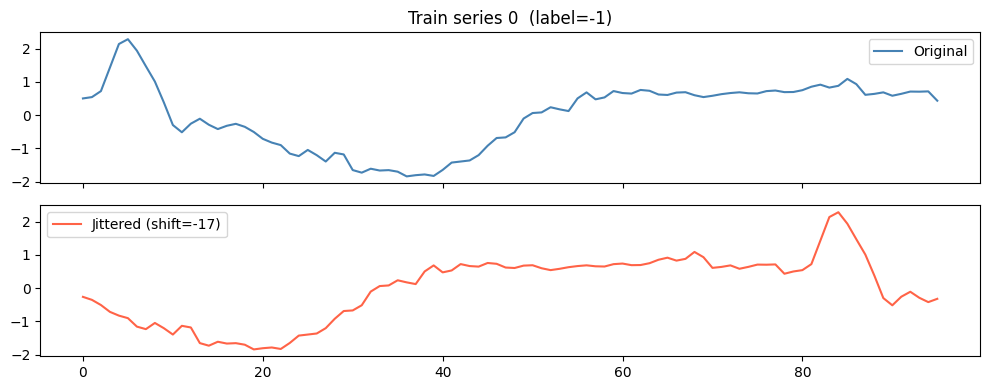

In [ ]:
RNG = np.random.default_rng(seed=RANDOM_STATE)   

def jitter_series(X, max_shift=20):
    """Return a copy of X where every row is circularly shifted by a
    random integer in [-max_shift, max_shift]."""
    shifts = RNG.integers(-max_shift, max_shift + 1, size=len(X))
    return np.array([np.roll(row, s) for row, s in zip(X, shifts)]), shifts

X_train_jit, shifts_train = jitter_series(X_train)
X_test_jit,  shifts_test  = jitter_series(X_test)

print(f"Train jitter — min: {shifts_train.min():+d}  max: {shifts_train.max():+d}  "
        f"mean: {shifts_train.mean():+.2f}")
print(f"Test  jitter — min: {shifts_test.min():+d}  max: {shifts_test.max():+d}  "
        f"mean: {shifts_test.mean():+.2f}")

# --- Sanity check: one original time series vs. its jittered version ---
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
idx = 0
axes[0].plot(X_train[idx], label="Original", color="steelblue")
axes[0].set_title(f"Train series {idx}  (label={y_train[idx]:.0f})")
axes[0].legend()
axes[1].plot(X_train_jit[idx], label=f"Jittered (shift={shifts_train[idx]:+d})", color="tomato")
axes[1].legend()
plt.tight_layout()
plt.show()


### B.2. Build and save classification models

In [ ]:
#Continue to use models from A.2.

Jittered models trained and saved.


### B.3. Load and apply models

In [16]:
model_files = {
    "knn_dtw_k5":       MODELS_DIR / "knn_dtw_k5.pkl",
    "knn_euclidean_k5": MODELS_DIR / "knn_euclidean_k5.pkl",
    "logreg":           MODELS_DIR / "logreg.pkl",
    "svm_rbf":          MODELS_DIR / "svm_rbf.pkl",
}

rows_jit = []

for name, path in model_files.items():

    model = joblib.load(path)

    y_pred = model.predict(X_test_jit)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_jit)[:, 1]
    else:
        y_prob = None

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[-1, 1]).ravel()

    rows_jit.append({
        "Model":                name,
        "Accuracy":             accuracy_score(y_test, y_pred),
        "Precision":            precision_score(y_test, y_pred, pos_label=1),
        "Recall (Sensitivity)": recall_score(y_test, y_pred, pos_label=1),
        "Specificity":          tn / (tn + fp),
        "F1":                   f1_score(y_test, y_pred, pos_label=1),
        "Balanced_Accuracy":    balanced_accuracy_score(y_test, y_pred),
        "AUC":                  roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan,
    })

results_jit_df = pd.DataFrame(rows_jit).sort_values("F1", ascending=False)

print("\n=== Jittered Test Set (trained on clean) ===")
print(results_jit_df.to_string(index=False))

# --- Degradation vs. original clean results ---
degradation = (
    results_df[["Model", "F1"]]
    .rename(columns={"F1": "F1_clean"})
    .merge(results_jit_df[["Model", "F1"]], on="Model")
    .assign(F1_drop=lambda d: d["F1_clean"] - d["F1"])
    .sort_values("F1_drop", ascending=False)
)

print("\n=== F1 degradation from jitter ===")
print(degradation.to_string(index=False))



=== Jittered Test Set (trained on clean) ===
           Model  Accuracy  Precision  Recall (Sensitivity)  Specificity       F1  Balanced_Accuracy      AUC
      knn_dtw_k5      0.70   0.729730              0.843750     0.444444 0.782609           0.644097 0.720703
          logreg      0.60   0.785714              0.515625     0.750000 0.622642           0.632812 0.638889
knn_euclidean_k5      0.48   0.620000              0.484375     0.472222 0.543860           0.478299 0.482205
         svm_rbf      0.56   0.833333              0.390625     0.861111 0.531915           0.625868 0.660590

=== F1 degradation from jitter ===
           Model  F1_clean       F1  F1_drop
knn_euclidean_k5  0.924242 0.543860 0.380383
         svm_rbf  0.900763 0.531915 0.368848
          logreg  0.870968 0.622642 0.248326
      knn_dtw_k5  0.844444 0.782609 0.061836


Stretch Data

In [23]:
def stretch_series(X, max_scale=0.5):
    """
    Time-stretch each series by scaling its time axis,
    keeping output length fixed.
    """
    n_samples, n_time = X.shape
    
    scales = RNG.uniform(1 - max_scale, 1 + max_scale, size=n_samples)
    X_stretched = []
    
    original_time = np.arange(n_time)
    
    for row, scale in zip(X, scales):
        # Warp time axis
        warped_time = np.linspace(0, n_time - 1, n_time) / scale
        
        # Clip to valid range
        warped_time = np.clip(warped_time, 0, n_time - 1)
        
        # Sample from original signal at warped times
        stretched = np.interp(warped_time, original_time, row)
        
        X_stretched.append(stretched)
    
    return np.array(X_stretched), scales

In [24]:
X_train_str, scales_train = stretch_series(X_train)
X_test_str,  scales_test  = stretch_series(X_test)

print(f"Train stretch — min: {scales_train.min():.3f}  "
      f"max: {scales_train.max():.3f}  "
      f"mean: {scales_train.mean():.3f}")

Train stretch — min: 0.514  max: 1.480  mean: 0.972


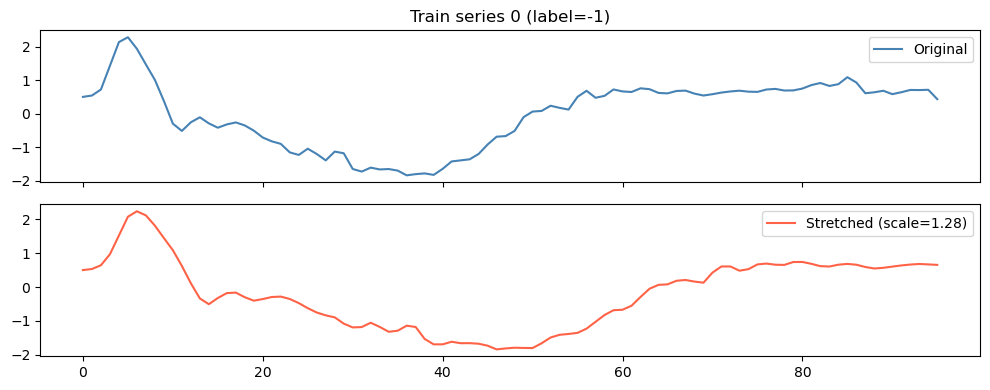

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
idx = 0

axes[0].plot(X_train[idx], label="Original", color="steelblue")
axes[0].set_title(f"Train series {idx} (label={y_train[idx]:.0f})")
axes[0].legend()

axes[1].plot(X_train_str[idx],
             label=f"Stretched (scale={scales_train[idx]:.2f})",
             color="tomato")
axes[1].legend()

plt.tight_layout()
plt.show()

In [26]:
model_files = {
    "knn_dtw_k5":       MODELS_DIR / "knn_dtw_k5.pkl",
    "knn_euclidean_k5": MODELS_DIR / "knn_euclidean_k5.pkl",
    "logreg":           MODELS_DIR / "logreg.pkl",
    "svm_rbf":          MODELS_DIR / "svm_rbf.pkl",
}

rows_str = []

for name, path in model_files.items():

    model = joblib.load(path)

    y_pred = model.predict(X_test_str)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_str)[:, 1]
    else:
        y_prob = None

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[-1, 1]).ravel()

    rows_str.append({
        "Model":                name,
        "Accuracy":             accuracy_score(y_test, y_pred),
        "Precision":            precision_score(y_test, y_pred, pos_label=1),
        "Recall (Sensitivity)": recall_score(y_test, y_pred, pos_label=1),
        "Specificity":          tn / (tn + fp),
        "F1":                   f1_score(y_test, y_pred, pos_label=1),
        "Balanced_Accuracy":    balanced_accuracy_score(y_test, y_pred),
        "AUC":                  roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan,
    })

results_str_df = pd.DataFrame(rows_str).sort_values("F1", ascending=False)

print("\n=== Stretched Test Set (trained on clean) ===")
print(results_str_df.to_string(index=False))

# --- Degradation vs. original clean results ---
degradation = (
    results_df[["Model", "F1"]]
    .rename(columns={"F1": "F1_clean"})
    .merge(results_str_df[["Model", "F1"]], on="Model")
    .assign(F1_drop=lambda d: d["F1_clean"] - d["F1"])
    .sort_values("F1_drop", ascending=False)
)

print("\n=== F1 degradation from str ===")
print(degradation.to_string(index=False))



=== Stretched Test Set (trained on clean) ===
           Model  Accuracy  Precision  Recall (Sensitivity)  Specificity       F1  Balanced_Accuracy      AUC
      knn_dtw_k5      0.75   0.819672              0.781250     0.694444 0.800000           0.737847 0.853082
          logreg      0.64   0.833333              0.546875     0.805556 0.660377           0.676215 0.719184
knn_euclidean_k5      0.62   0.795455              0.546875     0.750000 0.648148           0.648438 0.717448
         svm_rbf      0.56   0.777778              0.437500     0.777778 0.560000           0.607639 0.644097

=== F1 degradation from str ===
           Model  F1_clean       F1  F1_drop
         svm_rbf  0.900763 0.560000 0.340763
knn_euclidean_k5  0.924242 0.648148 0.276094
          logreg  0.870968 0.660377 0.210590
      knn_dtw_k5  0.844444 0.800000 0.044444
